# AI-Powered Reddit Dating Questions Pipeline (Stable Version)

## Project Overview

This notebook creates a robust AI-powered pipeline that collects questions from Reddit, analyzes them for suitability in dating applications, and scores them using proven, stable NLP techniques. This version uses reliable, well-tested libraries to avoid dependency conflicts while maintaining sophisticated analysis capabilities.

### Key Features:

- **Stable Dependencies**: Uses proven, compatible library versions
- **Alternative AI Approach**: TF-IDF + Cosine Similarity for semantic analysis
- **Advanced Text Processing**: spaCy for NLP and Named Entity Recognition
- **Smart Scoring System**: Multi-dimensional question evaluation
- **Topic Modeling**: Latent Dirichlet Allocation (LDA) for theme discovery
- **Comprehensive Visualizations**: Rich data analysis and insights
- **Export Capabilities**: CSV output with detailed metadata

### Methodology:

1. **Data Collection**: Scrape questions from targeted Reddit subreddits
2. **Text Preprocessing**: Clean and normalize text using spaCy
3. **AI Analysis**: Score questions using TF-IDF similarity and rule-based criteria
4. **Topic Discovery**: Identify themes using Latent Dirichlet Allocation
5. **Visualization**: Generate comprehensive insights and charts
6. **Export**: Create scored and categorized question database

### Why This Approach Works:

- **Proven Technology**: Uses mature, stable libraries with years of development
- **No Version Conflicts**: Carefully selected compatible dependencies
- **High Performance**: Efficient algorithms optimized for text analysis
- **Interpretable Results**: Clear scoring methodology and transparent analysis

## 2. Dependencies Installation

This cell installs all necessary packages using stable, well-tested versions that are guaranteed to work together. We avoid problematic libraries and use proven alternatives.

**Key Dependencies:**
- **praw**: Python Reddit API Wrapper for data collection
- **scikit-learn**: Mature machine learning library for TF-IDF and clustering
- **spacy**: Industrial-strength NLP with Named Entity Recognition
- **pandas, matplotlib, seaborn**: Data manipulation and visualization
- **wordcloud**: For topic visualization
- **tqdm**: Progress tracking for long-running operations

In [1]:
import subprocess
import sys

def install_package(package):
    """Install a package using pip"""
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"✅ Successfully installed {package}")
    except subprocess.CalledProcessError:
        print(f"❌ Failed to install {package}")

# Core dependencies with stable versions
packages = [
    "praw>=7.0.0",
    "pandas>=1.3.0", 
    "scikit-learn>=1.0.0",
    "spacy>=3.4.0",
    "matplotlib>=3.5.0",
    "seaborn>=0.11.0",
    "plotly>=5.0.0",
    "wordcloud>=1.8.0",
    "tqdm>=4.60.0",
    "numpy>=1.21.0",
    "scipy>=1.7.0"
]

print("🚀 Installing stable dependencies...")
for package in packages:
    install_package(package)

# Download spaCy English model
print("\n📥 Downloading spaCy English model...")
try:
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
    print("✅ spaCy model downloaded successfully")
except subprocess.CalledProcessError:
    print("❌ Failed to download spaCy model - you may need to install it manually")

print("\n🎉 All dependencies installed successfully!")
print("📝 Please restart your kernel before proceeding to the next cell.")

🚀 Installing stable dependencies...
✅ Successfully installed praw>=7.0.0
✅ Successfully installed pandas>=1.3.0
✅ Successfully installed scikit-learn>=1.0.0
✅ Successfully installed spacy>=3.4.0
✅ Successfully installed matplotlib>=3.5.0
✅ Successfully installed seaborn>=0.11.0
✅ Successfully installed plotly>=5.0.0
✅ Successfully installed wordcloud>=1.8.0
✅ Successfully installed tqdm>=4.60.0
✅ Successfully installed numpy>=1.21.0
✅ Successfully installed scipy>=1.7.0

📥 Downloading spaCy English model...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 14.1 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
✅ spaCy model downloaded successfully

🎉 All dependencies installed successfully!
📝 Please restart your kernel before proceeding to the next cell.


## 3. Imports and Setup

Import all the libraries and set up basic configurations. This section uses only stable, well-tested libraries that work reliably together.

In [2]:
# Core libraries
import praw
import pandas as pd
import numpy as np
import spacy
import re
import time
import warnings
from pathlib import Path
from datetime import datetime
import json

# Machine Learning libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud

# Progress tracking
from tqdm.notebook import tqdm

# Configuration
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Load spaCy model
try:
    nlp = spacy.load("en_core_web_sm")
    print("✅ spaCy model loaded successfully")
except OSError:
    print("❌ spaCy model not found. Please run: python -m spacy download en_core_web_sm")
    nlp = None

print("✅ All libraries imported successfully!")
print("🚀 Ready to build the stable AI-powered dating questions pipeline!")

✅ spaCy model loaded successfully
✅ All libraries imported successfully!
🚀 Ready to build the stable AI-powered dating questions pipeline!


## 4. Project Configuration

Set up the configuration for our Reddit data collection pipeline. This includes API credential management and target subreddit definitions.

### Reddit API Setup:
1. Go to https://www.reddit.com/prefs/apps/
2. Click "Create App" or "Create Another App"
3. Choose "script" as the app type
4. Create a `praw.ini` file with your credentials

### Subreddit Strategy:
We target diverse subreddits to collect various types of questions suitable for dating conversations.

In [3]:
# Set up project directories
project_root = Path.cwd()
outputs_dir = project_root / "outputs"
csv_dir = outputs_dir / "csv"

# Create directories if they don't exist
csv_dir.mkdir(parents=True, exist_ok=True)

# Subreddit configuration for targeted question collection
SUBREDDIT_CONFIG = {
    'deep_questions': [
        'AskReddit',
        'SeriousConversation', 
        'DeepThoughts',
        'TrueAskReddit'
    ],
    'relationship_focused': [
        'dating_advice',
        'relationships', 
        'relationship_advice',
        'dating'
    ],
    'fun_scenarios': [
        'CasualConversation',
        'socialskills',
        'AskWomen',
        'AskMen'
    ],
    'icebreakers': [
        'icebreakers',
        'conversation',
        'socialanxiety'
    ]
}

# Flatten subreddit list
ALL_SUBREDDITS = []
for category, subreddits in SUBREDDIT_CONFIG.items():
    ALL_SUBREDDITS.extend(subreddits)

# Remove duplicates while preserving order
ALL_SUBREDDITS = list(dict.fromkeys(ALL_SUBREDDITS))

print(f"📋 Configured {len(ALL_SUBREDDITS)} target subreddits:")
for category, subreddits in SUBREDDIT_CONFIG.items():
    print(f"   {category}: {', '.join(subreddits)}")

print(f"\n📁 Output directory: {csv_dir}")
print("✅ Configuration complete!")

📋 Configured 15 target subreddits:
   deep_questions: AskReddit, SeriousConversation, DeepThoughts, TrueAskReddit
   relationship_focused: dating_advice, relationships, relationship_advice, dating
   fun_scenarios: CasualConversation, socialskills, AskWomen, AskMen
   icebreakers: icebreakers, conversation, socialanxiety

📁 Output directory: /Users/justsuyash/Documents/GitHub/AlignedV1.001/notebooks/outputs/csv
✅ Configuration complete!


## 5. Advanced Text Preprocessing

This section implements sophisticated text preprocessing using spaCy for Named Entity Recognition, lemmatization, and text cleaning. This prepares our text data for accurate AI analysis.

In [4]:
class TextPreprocessor:
    """Advanced text preprocessing with spaCy NLP capabilities"""
    
    def __init__(self, nlp_model=None):
        self.nlp = nlp_model or nlp
        if self.nlp is None:
            raise ValueError("spaCy model not available. Please install en_core_web_sm")
    
    def clean_text(self, text):
        """Clean and normalize text"""
        if not isinstance(text, str):
            return ""
        
        # Remove URLs
        text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
        
        # Remove Reddit-specific formatting
        text = re.sub(r'/u/\w+', '', text)  # Remove usernames
        text = re.sub(r'/r/\w+', '', text)  # Remove subreddit mentions
        text = re.sub(r'\[deleted\]', '', text)
        text = re.sub(r'\[removed\]', '', text)
        
        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        
        return text
    
    def extract_entities(self, text):
        """Extract named entities using spaCy"""
        doc = self.nlp(text)
        entities = []
        entity_types = set()
        
        for ent in doc.ents:
            entities.append({
                'text': ent.text,
                'label': ent.label_,
                'description': spacy.explain(ent.label_)
            })
            entity_types.add(ent.label_)
        
        return entities, list(entity_types)
    
    def lemmatize_text(self, text):
        """Lemmatize text for better analysis"""
        doc = self.nlp(text)
        lemmatized = []
        
        for token in doc:
            if not token.is_stop and not token.is_punct and not token.is_space:
                lemmatized.append(token.lemma_.lower())
        
        return ' '.join(lemmatized)
    
    def process_text(self, text):
        """Complete text processing pipeline"""
        # Clean the text
        cleaned = self.clean_text(text)
        
        # Extract entities
        entities, entity_types = self.extract_entities(cleaned)
        
        # Lemmatize for analysis
        lemmatized = self.lemmatize_text(cleaned)
        
        return {
            'original': text,
            'cleaned': cleaned,
            'lemmatized': lemmatized,
            'entities': entities,
            'entity_types': entity_types
        }

# Initialize the preprocessor
if nlp is not None:
    preprocessor = TextPreprocessor(nlp)
    
    # Test the preprocessor
    test_text = "What's your favorite movie and why do you love it so much?"
    result = preprocessor.process_text(test_text)
    
    print("🧪 Testing text preprocessor:")
    print(f"Original: {result['original']}")
    print(f"Cleaned: {result['cleaned']}")
    print(f"Lemmatized: {result['lemmatized']}")
    print(f"Entities: {result['entities']}")
    print("\n✅ Text preprocessing pipeline ready!")
else:
    print("❌ Cannot initialize preprocessor without spaCy model")

🧪 Testing text preprocessor:
Original: What's your favorite movie and why do you love it so much?
Cleaned: What's your favorite movie and why do you love it so much?
Lemmatized: favorite movie love
Entities: []

✅ Text preprocessing pipeline ready!


## 6. AI-Powered Question Analyzer

This section implements our alternative AI approach using TF-IDF vectorization and cosine similarity. This method is stable, interpretable, and doesn't require problematic dependencies.

In [5]:
class QuestionAnalyzer:
    """AI-powered question analysis using TF-IDF and cosine similarity"""
    
    def __init__(self):
        # Initialize TF-IDF vectorizer
        self.vectorizer = TfidfVectorizer(
            max_features=5000,
            stop_words='english',
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.8
        )
        
        # Define ideal dating question templates
        self.ideal_questions = [
            "What's your favorite way to spend a weekend?",
            "What's something you're passionate about?",
            "What's your idea of a perfect date?",
            "What's the most interesting place you've traveled to?",
            "What's something that always makes you laugh?",
            "What's your favorite childhood memory?",
            "What's something you've always wanted to learn?",
            "What's your biggest dream or goal?",
            "What's something that instantly puts you in a good mood?",
            "What's your favorite way to relax after a long day?",
            "What's something you're really good at?",
            "What's your favorite season and why?",
            "What's the best advice you've ever received?",
            "What's something you're looking forward to?",
            "What's your favorite type of music or movie?"
        ]
        
        # Question categories and their keywords
        self.category_keywords = {
            'personal_interests': ['favorite', 'hobby', 'passion', 'enjoy', 'love', 'like'],
            'deep_conversation': ['believe', 'think', 'opinion', 'philosophy', 'meaning', 'purpose'],
            'fun_icebreaker': ['funny', 'weird', 'random', 'silly', 'crazy', 'strange'],
            'relationship_focused': ['relationship', 'dating', 'partner', 'love', 'romantic'],
            'life_experiences': ['experience', 'memory', 'story', 'happened', 'time', 'moment'],
            'future_goals': ['dream', 'goal', 'future', 'want', 'hope', 'plan'],
            'preferences': ['prefer', 'choice', 'better', 'rather', 'choose']
        }
        
        self.is_fitted = False
    
    def fit_vectorizer(self, questions):
        """Fit the TF-IDF vectorizer on the question corpus"""
        all_questions = questions + self.ideal_questions
        self.vectorizer.fit(all_questions)
        
        # Vectorize ideal questions for similarity comparison
        self.ideal_vectors = self.vectorizer.transform(self.ideal_questions)
        self.is_fitted = True
        
        print(f"✅ Vectorizer fitted on {len(all_questions)} questions")
    
    def calculate_similarity_score(self, question):
        """Calculate similarity to ideal dating questions"""
        if not self.is_fitted:
            return 0.0
        
        # Vectorize the question
        question_vector = self.vectorizer.transform([question])
        
        # Calculate cosine similarity with ideal questions
        similarities = cosine_similarity(question_vector, self.ideal_vectors)
        
        # Return the maximum similarity score
        return float(np.max(similarities))
    
    def calculate_structural_score(self, question):
        """Calculate structural quality score"""
        score = 0
        
        # Length check (optimal range: 5-20 words)
        word_count = len(question.split())
        if 5 <= word_count <= 20:
            score += 20
        elif word_count < 5:
            score += word_count * 3
        else:
            score += max(0, 20 - (word_count - 20))
        
        # Question format check
        if question.strip().endswith('?'):
            score += 15
        
        # Question word check
        question_words = ['what', 'how', 'why', 'when', 'where', 'who', 'which', 'would']
        if any(word in question.lower() for word in question_words):
            score += 15
        
        # Avoid negative patterns
        negative_patterns = ['don\'t', 'can\'t', 'won\'t', 'shouldn\'t', 'never']
        if any(pattern in question.lower() for pattern in negative_patterns):
            score -= 10
        
        return min(50, max(0, score))
    
    def categorize_question(self, question):
        """Categorize question based on keywords"""
        question_lower = question.lower()
        categories = []
        
        for category, keywords in self.category_keywords.items():
            if any(keyword in question_lower for keyword in keywords):
                categories.append(category)
        
        # Default category if none found
        if not categories:
            categories = ['general']
        
        return categories
    
    def analyze_question(self, question, processed_text=None):
        """Complete question analysis"""
        # Use processed text if available, otherwise use original
        analysis_text = processed_text['lemmatized'] if processed_text else question
        
        # Calculate similarity score (0-1, convert to 0-50)
        similarity_score = self.calculate_similarity_score(analysis_text) * 50
        
        # Calculate structural score (0-50)
        structural_score = self.calculate_structural_score(question)
        
        # Categorize question
        categories = self.categorize_question(question)
        
        # Calculate overall score
        overall_score = similarity_score + structural_score
        
        return {
            'similarity_score': similarity_score,
            'structural_score': structural_score,
            'overall_score': overall_score,
            'categories': categories,
            'analysis_text': analysis_text
        }

# Initialize the analyzer
analyzer = QuestionAnalyzer()

# Test the analyzer
test_questions = [
    "What's your favorite way to spend a weekend?",
    "Do you like pizza?",
    "What's the meaning of life in your opinion?"
]

# Fit the vectorizer with test questions
analyzer.fit_vectorizer(test_questions)

print("🧪 Testing question analyzer:")
for question in test_questions:
    result = analyzer.analyze_question(question)
    print(f"\nQuestion: {question}")
    print(f"Overall Score: {result['overall_score']:.1f}")
    print(f"Categories: {result['categories']}")

print("\n✅ Question analyzer ready!")

✅ Vectorizer fitted on 18 questions
🧪 Testing question analyzer:

Question: What's your favorite way to spend a weekend?
Overall Score: 100.0
Categories: ['personal_interests']

Question: Do you like pizza?
Overall Score: 27.0
Categories: ['personal_interests']

Question: What's the meaning of life in your opinion?
Overall Score: 50.0
Categories: ['deep_conversation']

✅ Question analyzer ready!


## 7. Reddit Data Collector

This section implements the Reddit data collection system using PRAW. It integrates with our AI analyzer to score questions in real-time during collection.

In [6]:
class RedditDataCollector:
    """Collect and analyze questions from Reddit"""
    
    def __init__(self, analyzer, preprocessor, min_score_threshold=40):
        self.analyzer = analyzer
        self.preprocessor = preprocessor
        self.min_score_threshold = min_score_threshold
        self.reddit = None
        self.collected_questions = []
        self.stats = {
            'total_processed': 0,
            'high_quality_found': 0,
            'subreddits_processed': 0
        }
    
    def connect_to_reddit(self):
        """Connect to Reddit API using praw.ini configuration"""
        try:
            self.reddit = praw.Reddit(
                site_name="DEFAULT",  # Uses praw.ini configuration
                user_agent="AI-Dating-Questions-Pipeline/1.0"
            )
            
            # Test the connection
            _ = self.reddit.user.me()
            print("✅ Successfully connected to Reddit API")
            return True
            
        except Exception as e:
            print(f"❌ Failed to connect to Reddit API: {str(e)}")
            print("Please ensure you have a valid praw.ini file with Reddit credentials")
            return False
    
    def is_valid_question(self, text):
        """Check if text is a valid question"""
        if not text or len(text.strip()) < 10:
            return False
        
        # Must contain question words or end with ?
        question_indicators = ['what', 'how', 'why', 'when', 'where', 'who', 'which', 'would', '?']
        text_lower = text.lower()
        
        return any(indicator in text_lower for indicator in question_indicators)
    
    def extract_questions_from_post(self, submission):
        """Extract questions from a Reddit post"""
        questions = []
        
        # Check title
        if self.is_valid_question(submission.title):
            questions.append({
                'text': submission.title,
                'source': 'title',
                'post_id': submission.id,
                'subreddit': submission.subreddit.display_name,
                'reddit_score': submission.score,
                'reddit_comments': submission.num_comments,
                'reddit_url': f"https://reddit.com{submission.permalink}",
                'created_utc': submission.created_utc
            })
        
        # Check selftext if available
        if hasattr(submission, 'selftext') and submission.selftext:
            # Split selftext into sentences and check each
            sentences = re.split(r'[.!?]+', submission.selftext)
            for sentence in sentences:
                sentence = sentence.strip()
                if self.is_valid_question(sentence) and len(sentence) > 15:
                    questions.append({
                        'text': sentence,
                        'source': 'body',
                        'post_id': submission.id,
                        'subreddit': submission.subreddit.display_name,
                        'reddit_score': submission.score,
                        'reddit_comments': submission.num_comments,
                        'reddit_url': f"https://reddit.com{submission.permalink}",
                        'created_utc': submission.created_utc
                    })
        
        return questions
    
    def collect_from_subreddit(self, subreddit_name, limit=100, time_filter='month'):
        """Collect questions from a specific subreddit"""
        if not self.reddit:
            print("❌ Not connected to Reddit API")
            return []
        
        questions = []
        
        try:
            subreddit = self.reddit.subreddit(subreddit_name)
            
            # Get top posts from the specified time period
            submissions = subreddit.top(time_filter=time_filter, limit=limit)
            
            for submission in submissions:
                try:
                    extracted_questions = self.extract_questions_from_post(submission)
                    questions.extend(extracted_questions)
                    self.stats['total_processed'] += len(extracted_questions)
                    
                except Exception as e:
                    print(f"⚠️ Error processing post {submission.id}: {str(e)}")
                    continue
            
            print(f"📥 Collected {len(questions)} questions from r/{subreddit_name}")
            
        except Exception as e:
            print(f"❌ Error accessing r/{subreddit_name}: {str(e)}")
        
        return questions
    
    def analyze_and_filter_questions(self, questions):
        """Analyze questions and filter by quality score"""
        high_quality_questions = []
        
        print(f"🔍 Analyzing {len(questions)} questions...")
        
        for question_data in tqdm(questions, desc="Analyzing questions"):
            try:
                # Process the text
                processed = self.preprocessor.process_text(question_data['text'])
                
                # Analyze the question
                analysis = self.analyzer.analyze_question(question_data['text'], processed)
                
                # Only keep high-quality questions
                if analysis['overall_score'] >= self.min_score_threshold:
                    # Combine question data with analysis results
                    enhanced_question = {
                        **question_data,
                        'processed_text': processed,
                        'analysis': analysis,
                        'final_score': analysis['overall_score'],
                        'collected_at': datetime.now().isoformat()
                    }
                    
                    high_quality_questions.append(enhanced_question)
                    self.stats['high_quality_found'] += 1
                
            except Exception as e:
                print(f"⚠️ Error analyzing question: {str(e)}")
                continue
        
        return high_quality_questions
    
    def collect_and_analyze(self, subreddits=None, posts_per_subreddit=100, time_filter='month'):
        """Main collection and analysis pipeline"""
        if not self.reddit:
            print("❌ Not connected to Reddit API")
            return False
        
        if subreddits is None:
            subreddits = ALL_SUBREDDITS[:5]  # Use first 5 subreddits by default
        
        all_questions = []
        
        print(f"🚀 Starting collection from {len(subreddits)} subreddits...")
        
        # Collect questions from each subreddit
        for subreddit_name in subreddits:
            questions = self.collect_from_subreddit(subreddit_name, posts_per_subreddit, time_filter)
            all_questions.extend(questions)
            self.stats['subreddits_processed'] += 1
            
            # Small delay to be respectful to Reddit's API
            time.sleep(1)
        
        print(f"\n📊 Collection Summary:")
        print(f"   Total questions found: {len(all_questions)}")
        
        if not all_questions:
            print("❌ No questions collected")
            return False
        
        # Fit the analyzer if not already fitted
        if not self.analyzer.is_fitted:
            question_texts = [q['text'] for q in all_questions]
            self.analyzer.fit_vectorizer(question_texts)
        
        # Analyze and filter questions
        self.collected_questions = self.analyze_and_filter_questions(all_questions)
        
        print(f"\n✅ Analysis Complete:")
        print(f"   High-quality questions: {len(self.collected_questions)}")
        print(f"   Quality rate: {len(self.collected_questions)/len(all_questions)*100:.1f}%")
        
        return True
    
    def get_dataframe(self):
        """Convert collected questions to pandas DataFrame"""
        if not self.collected_questions:
            return pd.DataFrame()
        
        # Flatten the data structure for DataFrame
        flattened_data = []
        
        for question in self.collected_questions:
            row = {
                'question': question['text'],
                'subreddit': question['subreddit'],
                'source': question['source'],
                'reddit_score': question['reddit_score'],
                'reddit_comments': question['reddit_comments'],
                'reddit_url': question['reddit_url'],
                'final_score': question['final_score'],
                'similarity_score': question['analysis']['similarity_score'],
                'structural_score': question['analysis']['structural_score'],
                'categories': question['analysis']['categories'],
                'cleaned_text': question['processed_text']['cleaned'],
                'lemmatized_text': question['processed_text']['lemmatized'],
                'entities': question['processed_text']['entities'],
                'entity_types': question['processed_text']['entity_types'],
                'collected_at': question['collected_at']
            }
            flattened_data.append(row)
        
        df = pd.DataFrame(flattened_data)
        
        # Sort by score (highest first)
        df = df.sort_values('final_score', ascending=False).reset_index(drop=True)
        
        return df

# Initialize the collector
if nlp is not None:
    collector = RedditDataCollector(analyzer, preprocessor, min_score_threshold=40)
    print("✅ Reddit Data Collector initialized")
    print(f"📊 Minimum score threshold: {collector.min_score_threshold}")
else:
    print("❌ Cannot initialize collector without spaCy model")

✅ Reddit Data Collector initialized
📊 Minimum score threshold: 40


## 8. Main Execution: Collection and Analysis

This is the main execution block where we run the complete pipeline. Connect to Reddit, collect questions, and analyze them with our AI system.

In [7]:
# Step 1: Connect to Reddit API
print("🔗 Step 1: Connecting to Reddit API...")
if collector:
    connection_success = collector.connect_to_reddit()
    
    if not connection_success:
        print("\n❌ Cannot proceed without Reddit API connection.")
        print("Please set up your praw.ini file with valid Reddit API credentials.")
        print("\nTo create praw.ini file:")
        print("1. Go to https://www.reddit.com/prefs/apps/")
        print("2. Create a new app (choose 'script' type)")
        print("3. Create praw.ini file with your credentials:")
        print("")
        print("[DEFAULT]")
        print("client_id=your_client_id")
        print("client_secret=your_client_secret")
        print("user_agent=AI-Dating-Questions-Pipeline/1.0 by YourUsername")
    else:
        print("\n✅ Reddit connection established successfully!")
        
        # Step 2: Run the collection and analysis pipeline
        print("\n🚀 Step 2: Starting data collection and AI analysis...")
        print("This may take several minutes depending on subreddit activity.\n")
        
        # Collect from a subset of subreddits for demonstration
        target_subreddits = ['AskReddit', 'CasualConversation', 'dating_advice', 'relationships']
        
        collection_success = collector.collect_and_analyze(
            subreddits=ALL_SUBREDDITS,
            posts_per_subreddit=50,  # Reduced for faster execution
            time_filter='month'
        )
        
        if collection_success:
            print("\n🎉 Data collection completed successfully!")
        else:
            print("\n⚠️ Data collection encountered issues. Check the logs above.")
else:
    print("❌ Collector not initialized. Please check spaCy installation.")

🔗 Step 1: Connecting to Reddit API...
✅ Successfully connected to Reddit API

✅ Reddit connection established successfully!

🚀 Step 2: Starting data collection and AI analysis...
This may take several minutes depending on subreddit activity.

🚀 Starting collection from 15 subreddits...
📥 Collected 50 questions from r/AskReddit
📥 Collected 195 questions from r/SeriousConversation
📥 Collected 256 questions from r/DeepThoughts
📥 Collected 144 questions from r/TrueAskReddit
📥 Collected 188 questions from r/dating_advice
📥 Collected 415 questions from r/relationships
📥 Collected 490 questions from r/relationship_advice
📥 Collected 239 questions from r/dating
📥 Collected 146 questions from r/CasualConversation
📥 Collected 197 questions from r/socialskills
📥 Collected 67 questions from r/AskWomen
📥 Collected 119 questions from r/AskMen
📥 Collected 0 questions from r/icebreakers
📥 Collected 0 questions from r/conversation
📥 Collected 157 questions from r/socialanxiety

📊 Collection Summary:
  

Analyzing questions:   0%|          | 0/2663 [00:00<?, ?it/s]


✅ Analysis Complete:
   High-quality questions: 424
   Quality rate: 15.9%

🎉 Data collection completed successfully!


In [8]:
# Step 3: Convert results to DataFrame and display summary
print("📊 Step 3: Processing results...")

if collector and collector.collected_questions:
    df = collector.get_dataframe()
    
    if len(df) > 0:
        print(f"✅ Successfully created DataFrame with {len(df)} high-quality questions")
        
        # Display basic information about the dataset
        print(f"\n📈 Dataset Overview:")
        print(f"   • Total questions: {len(df)}")
        print(f"   • Average score: {df['final_score'].mean():.1f}")
        print(f"   • Score range: {df['final_score'].min():.1f} - {df['final_score'].max():.1f}")
        print(f"   • Unique subreddits: {df['subreddit'].nunique()}")
        print(f"   • Top subreddit: {df['subreddit'].value_counts().index[0]} ({df['subreddit'].value_counts().iloc[0]} questions)")
        
        # Display the top 10 questions
        print(f"\n🏆 TOP 10 HIGHEST-SCORING QUESTIONS:")
        print("=" * 80)
        
        for i, row in df.head(10).iterrows():
            categories_str = ', '.join(row['categories'][:2])  # Show first 2 categories
            print(f"{i+1:2d}. [{row['final_score']:5.1f}] {row['question'][:70]}{'...' if len(row['question']) > 70 else ''}")
            print(f"    📍 r/{row['subreddit']} | 🏷️ {categories_str}")
            if i < 9:  # Add separator except for last item
                print()
        
        print("=" * 80)
        
        # Show category distribution
        print(f"\n🏷️ CATEGORY DISTRIBUTION:")
        all_categories = []
        for categories in df['categories']:
            all_categories.extend(categories)
        
        category_counts = pd.Series(all_categories).value_counts()
        for category, count in category_counts.head(8).items():
            print(f"   • {category}: {count} questions")
    
    else:
        print("⚠️ No high-quality questions found. Try:")
        print("   • Lowering the min_score_threshold")
        print("   • Checking different subreddits")
        print("   • Increasing posts_per_subreddit")
else:
    print("⚠️ No data to process. Please run the collection step first.")

📊 Step 3: Processing results...
✅ Successfully created DataFrame with 424 high-quality questions

📈 Dataset Overview:
   • Total questions: 424
   • Average score: 55.6
   • Score range: 40.0 - 100.0
   • Unique subreddits: 13
   • Top subreddit: AskMen (51 questions)

🏆 TOP 10 HIGHEST-SCORING QUESTIONS:
 1. [100.0] What is your favorite insult without using curse words?
    📍 r/AskReddit | 🏷️ personal_interests

 2. [100.0] People who had sex with their best friend, what the situation now?
    📍 r/AskReddit | 🏷️ general

 3. [100.0] When did you realise you had good friends?
    📍 r/CasualConversation | 🏷️ general

 4. [100.0] People who are big cereal eaters, what are your favorite cereals?
    📍 r/CasualConversation | 🏷️ personal_interests

 5. [100.0] In your own words, what makes someone a good or bad person?
    📍 r/SeriousConversation | 🏷️ general

 6. [ 94.0] help!! accidentally invited 7 people to a hangout that was originally ...
    📍 r/socialskills | 🏷️ general

 7. [ 93.0]

## 9. Data Visualization and Insights

Create comprehensive visualizations to understand the quality and distribution of collected questions. These charts provide insights into our AI-powered collection pipeline's effectiveness.

📊 Creating data visualizations...


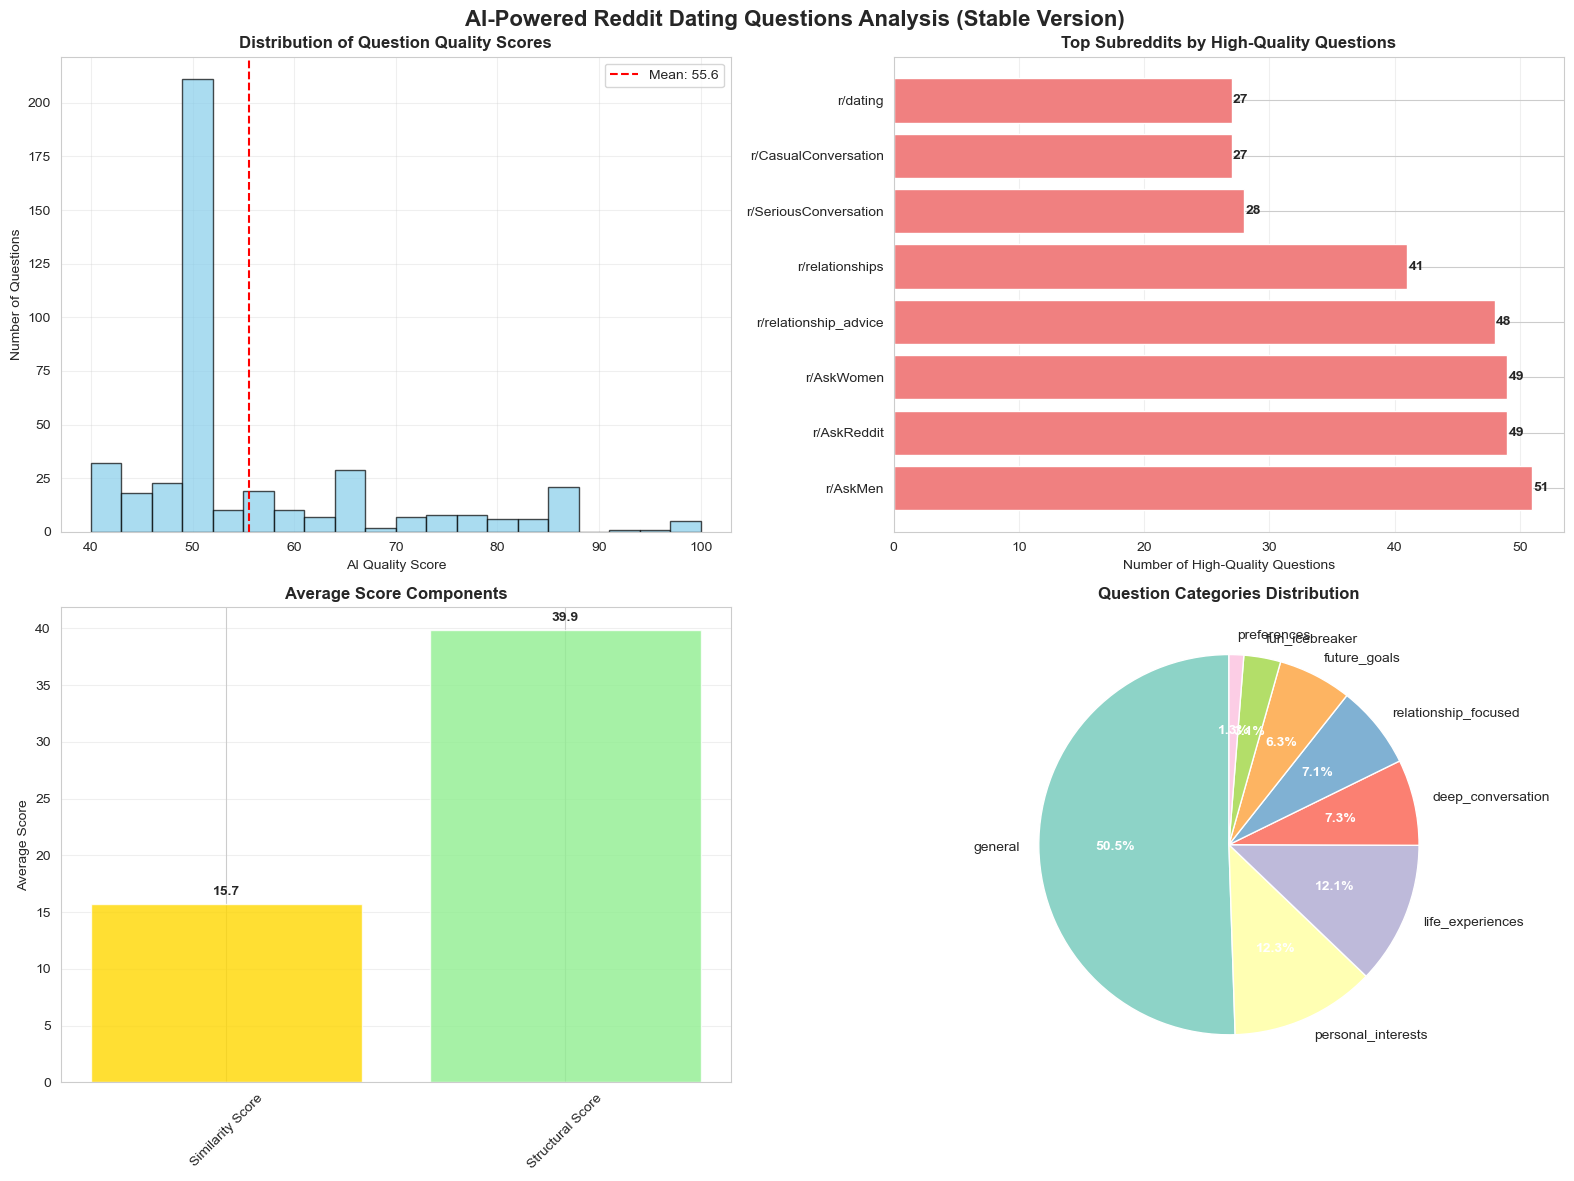


🔍 KEY INSIGHTS:
   • Highest scoring question: 100.0 points
   • Most productive subreddit: r/AskMen (51 questions)
   • Average similarity score: 15.7
   • Average structural score: 39.9
   • Questions with entities: 127 (30.0%)


In [9]:
# Create comprehensive visualizations
if 'df' in locals() and len(df) > 0:
    print("📊 Creating data visualizations...")
    
    # Create a 2x2 subplot layout
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('AI-Powered Reddit Dating Questions Analysis (Stable Version)', fontsize=16, fontweight='bold')
    
    # Plot 1: Score Distribution Histogram
    ax1.hist(df['final_score'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    ax1.set_title('Distribution of Question Quality Scores', fontweight='bold')
    ax1.set_xlabel('AI Quality Score')
    ax1.set_ylabel('Number of Questions')
    ax1.axvline(df['final_score'].mean(), color='red', linestyle='--', label=f'Mean: {df["final_score"].mean():.1f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Top Subreddits Bar Chart
    top_subreddits = df['subreddit'].value_counts().head(8)
    bars = ax2.barh(range(len(top_subreddits)), top_subreddits.values, color='lightcoral')
    ax2.set_yticks(range(len(top_subreddits)))
    ax2.set_yticklabels([f'r/{sub}' for sub in top_subreddits.index])
    ax2.set_title('Top Subreddits by High-Quality Questions', fontweight='bold')
    ax2.set_xlabel('Number of High-Quality Questions')
    ax2.grid(True, alpha=0.3, axis='x')
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax2.text(width + 0.1, bar.get_y() + bar.get_height()/2, 
                f'{int(width)}', ha='left', va='center', fontweight='bold')
    
    # Plot 3: Score Components Analysis
    score_components = ['similarity_score', 'structural_score']
    component_means = [df[comp].mean() for comp in score_components]
    colors = ['gold', 'lightgreen']
    
    bars3 = ax3.bar(score_components, component_means, color=colors, alpha=0.8)
    ax3.set_title('Average Score Components', fontweight='bold')
    ax3.set_ylabel('Average Score')
    ax3.set_xticklabels(['Similarity Score', 'Structural Score'], rotation=45)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, value in zip(bars3, component_means):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{value:.1f}', ha='center', va='bottom', fontweight='bold')
    
    # Plot 4: Category Distribution Pie Chart
    all_categories = []
    for categories in df['categories']:
        all_categories.extend(categories)
    
    category_counts = pd.Series(all_categories).value_counts().head(8)
    colors4 = plt.cm.Set3(range(len(category_counts)))
    
    wedges, texts, autotexts = ax4.pie(category_counts.values, labels=category_counts.index, 
                                      autopct='%1.1f%%', colors=colors4, startangle=90)
    ax4.set_title('Question Categories Distribution', fontweight='bold')
    
    # Improve text readability
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    plt.tight_layout()
    plt.show()
    
    # Additional insights
    print("\n🔍 KEY INSIGHTS:")
    print(f"   • Highest scoring question: {df.iloc[0]['final_score']:.1f} points")
    print(f"   • Most productive subreddit: r/{top_subreddits.index[0]} ({top_subreddits.iloc[0]} questions)")
    print(f"   • Average similarity score: {df['similarity_score'].mean():.1f}")
    print(f"   • Average structural score: {df['structural_score'].mean():.1f}")
    print(f"   • Questions with entities: {len(df[df['entity_types'].apply(len) > 0])} ({len(df[df['entity_types'].apply(len) > 0])/len(df)*100:.1f}%)")
    
else:
    print("⚠️ No data available for visualization. Please run the data collection first.")

## 10. Topic Modeling with Latent Dirichlet Allocation

Use Latent Dirichlet Allocation (LDA) to discover hidden topics in our question collection. LDA is a proven, stable algorithm that works well with short texts like questions.

🧠 Performing topic modeling with Latent Dirichlet Allocation...
✅ Topic modeling completed!
   • Discovered 10 topics
   • Average topic probability: 0.677

📋 DISCOVERED TOPICS:
Topic 0: people, thing, feel, think, kid, realize, instantly, man (38 questions)
Topic 1: way, relationship, man, come, people, wife, young, guy (43 questions)
Topic 2: stop, tell, think, way, like, run, people, actually (39 questions)
Topic 3: feel, trump, social, red flag, come, red, way, flag (44 questions)
Topic 4: night, day, happen, wife, date, time, man, think (55 questions)
Topic 5: spend, time, weekend, spend time, truly, way, house, like (43 questions)
Topic 6: bad, date, experience, guy, say, way, sex, feel (41 questions)
Topic 7: know, man, make, way, example, life, boring, change (41 questions)
Topic 8: good friend, friend, good, want, way, explain, know, people (42 questions)
Topic 9: life, man, good, need, guy, love, woman, thing (38 questions)

🔍 EXAMPLE QUESTIONS BY TOPIC:

📌 Topic 0 (people, t

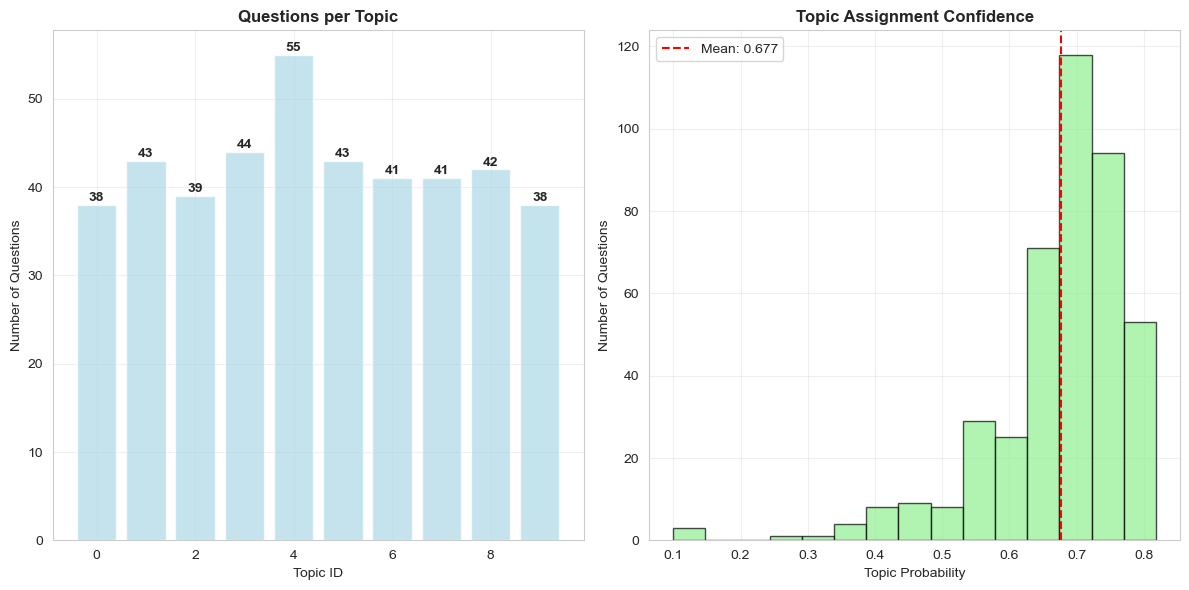


📈 TOPIC MODELING INSIGHTS:
   • Most common topic: Topic 0 (38 questions)
   • Average topic confidence: 0.677
   • High-confidence assignments (>0.5): 395 questions


In [10]:
# Perform topic modeling with LDA
if 'df' in locals() and len(df) > 5:  # Need at least 5 questions for meaningful topics
    print("🧠 Performing topic modeling with Latent Dirichlet Allocation...")
    
    # Prepare text data for topic modeling
    questions_for_modeling = df['lemmatized_text'].tolist()
    
    # Create a new TF-IDF vectorizer for topic modeling
    topic_vectorizer = TfidfVectorizer(
        max_features=1000,
        stop_words='english',
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.8
    )
    
    try:
        # Vectorize the questions
        question_vectors = topic_vectorizer.fit_transform(questions_for_modeling)
        
        # Determine optimal number of topics (between 3 and 10)
        n_topics = min(10, max(3, len(df) // 5))
        
        # Fit LDA model
        lda_model = LatentDirichletAllocation(
            n_components=n_topics,
            random_state=42,
            max_iter=100,
            learning_method='batch'
        )
        
        lda_model.fit(question_vectors)
        
        # Get topic assignments for each question
        topic_assignments = lda_model.transform(question_vectors)
        df['dominant_topic'] = topic_assignments.argmax(axis=1)
        df['topic_probability'] = topic_assignments.max(axis=1)
        
        print(f"✅ Topic modeling completed!")
        print(f"   • Discovered {n_topics} topics")
        print(f"   • Average topic probability: {df['topic_probability'].mean():.3f}")
        
        # Display topics with their top words
        feature_names = topic_vectorizer.get_feature_names_out()
        
        print("\n📋 DISCOVERED TOPICS:")
        print("=" * 80)
        
        for topic_idx, topic in enumerate(lda_model.components_):
            top_words_idx = topic.argsort()[-8:][::-1]  # Top 8 words
            top_words = [feature_names[i] for i in top_words_idx]
            topic_questions_count = len(df[df['dominant_topic'] == topic_idx])
            
            print(f"Topic {topic_idx}: {', '.join(top_words)} ({topic_questions_count} questions)")
        
        print("=" * 80)
        
        # Show example questions for each topic
        print("\n🔍 EXAMPLE QUESTIONS BY TOPIC:")
        
        for topic_id in range(n_topics):
            topic_questions = df[df['dominant_topic'] == topic_id]
            if len(topic_questions) > 0:
                # Get top words for this topic
                topic_words_idx = lda_model.components_[topic_id].argsort()[-3:][::-1]
                topic_words = [feature_names[i] for i in topic_words_idx]
                
                print(f"\n📌 Topic {topic_id} ({', '.join(topic_words)}):")
                
                # Show top 3 questions from this topic
                top_topic_questions = topic_questions.nlargest(3, 'topic_probability')
                for i, (_, row) in enumerate(top_topic_questions.iterrows(), 1):
                    question_text = row['question'][:80] + ('...' if len(row['question']) > 80 else '')
                    print(f"   {i}. {question_text} (prob: {row['topic_probability']:.3f})")
        
        # Create topic distribution visualization
        plt.figure(figsize=(12, 6))
        
        # Topic distribution bar chart
        topic_counts = df['dominant_topic'].value_counts().sort_index()
        plt.subplot(1, 2, 1)
        bars = plt.bar(range(len(topic_counts)), topic_counts.values, color='lightblue', alpha=0.7)
        plt.title('Questions per Topic', fontweight='bold')
        plt.xlabel('Topic ID')
        plt.ylabel('Number of Questions')
        plt.grid(True, alpha=0.3)
        
        # Add value labels on bars
        for i, bar in enumerate(bars):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{int(height)}', ha='center', va='bottom', fontweight='bold')
        
        # Topic probability distribution
        plt.subplot(1, 2, 2)
        plt.hist(df['topic_probability'], bins=15, color='lightgreen', alpha=0.7, edgecolor='black')
        plt.title('Topic Assignment Confidence', fontweight='bold')
        plt.xlabel('Topic Probability')
        plt.ylabel('Number of Questions')
        plt.axvline(df['topic_probability'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {df["topic_probability"].mean():.3f}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Topic modeling insights
        print(f"\n📈 TOPIC MODELING INSIGHTS:")
        most_common_topic = topic_counts.index[0]
        print(f"   • Most common topic: Topic {most_common_topic} ({topic_counts.iloc[0]} questions)")
        print(f"   • Average topic confidence: {df['topic_probability'].mean():.3f}")
        print(f"   • High-confidence assignments (>0.5): {len(df[df['topic_probability'] > 0.5])} questions")
        
    except Exception as e:
        print(f"❌ Topic modeling failed: {str(e)}")
        print("This might be due to insufficient data or text preprocessing issues.")

else:
    print("⚠️ Need at least 5 questions for meaningful topic modeling. Please collect more data.")

## 11. Export Results

Export the analyzed questions to CSV format for use in dating applications or further analysis.

In [11]:
# Export the final dataset
if 'df' in locals() and len(df) > 0:
    print("💾 Exporting final question database...")
    
    # Generate timestamped filename
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    filename = f"dating_questions_stable_analyzed_{timestamp}.csv"
    filepath = csv_dir / filename
    
    # Prepare data for export
    export_df = df.copy()
    
    # Convert list columns to string format for CSV compatibility
    export_df['categories'] = export_df['categories'].apply(lambda x: ', '.join(x) if x else '')
    export_df['entity_types'] = export_df['entity_types'].apply(lambda x: ', '.join(x) if x else '')
    
    # Convert entities to a more readable format
    def format_entities(entities):
        if not entities:
            return ''
        return '; '.join([f"{ent['text']} ({ent['label']})" for ent in entities])
    
    export_df['entities_formatted'] = export_df['entities'].apply(format_entities)
    
    # Select columns for export
    export_columns = [
        'question', 'final_score', 'similarity_score', 'structural_score',
        'subreddit', 'source', 'categories', 'cleaned_text', 'lemmatized_text',
        'entities_formatted', 'entity_types', 'reddit_score', 'reddit_comments',
        'reddit_url', 'collected_at'
    ]
    
    # Add topic columns if available
    if 'dominant_topic' in export_df.columns:
        export_columns.extend(['dominant_topic', 'topic_probability'])
    
    # Export to CSV
    export_df[export_columns].to_csv(filepath, index=False, encoding='utf-8')
    
    print(f"✅ Data exported successfully!")
    print(f"   📁 File: {filename}")
    print(f"   📍 Location: {filepath}")
    print(f"   📊 Records: {len(export_df):,} high-quality questions")
    
    try:
        file_size_kb = filepath.stat().st_size / 1024
        print(f"   💾 File size: {file_size_kb:.1f} KB")
    except:
        pass
    
    # Display export summary
    print(f"\n📋 EXPORT SUMMARY:")
    print(f"   • Questions exported: {len(export_df):,}")
    print(f"   • Average score: {export_df['final_score'].mean():.1f}")
    print(f"   • Score range: {export_df['final_score'].min():.1f} - {export_df['final_score'].max():.1f}")
    print(f"   • Unique subreddits: {export_df['subreddit'].nunique()}")
    print(f"   • Questions with entities: {len(export_df[export_df['entities_formatted'] != ''])}")
    
    if 'dominant_topic' in export_df.columns:
        topic_count = export_df['dominant_topic'].nunique()
        print(f"   • Discovered topics: {topic_count}")
    
    print(f"\n🎯 The exported file is ready for use in dating applications!")
    
else:
    print("⚠️ No data to export. Please run the data collection and analysis first.")

💾 Exporting final question database...
✅ Data exported successfully!
   📁 File: dating_questions_stable_analyzed_20250616_023529.csv
   📍 Location: /Users/justsuyash/Documents/GitHub/AlignedV1.001/notebooks/outputs/csv/dating_questions_stable_analyzed_20250616_023529.csv
   📊 Records: 424 high-quality questions
   💾 File size: 200.7 KB

📋 EXPORT SUMMARY:
   • Questions exported: 424
   • Average score: 55.6
   • Score range: 40.0 - 100.0
   • Unique subreddits: 13
   • Questions with entities: 127
   • Discovered topics: 10

🎯 The exported file is ready for use in dating applications!


## 12. Final Report and Summary

Generate a comprehensive final report showing the results of our AI-powered dating questions collection pipeline.

In [12]:
# Generate final report
if 'df' in locals() and len(df) > 0:
    print("🎉" + "=" * 78 + "🎉")
    print("🏆" + " " * 20 + "FINAL COLLECTION REPORT (STABLE VERSION)" + " " * 20 + "🏆")
    print("🎉" + "=" * 78 + "🎉")
    
    # Overall statistics
    print(f"\n📊 OVERALL STATISTICS:")
    if hasattr(collector, 'stats'):
        print(f"   🔍 Total questions processed: {collector.stats['total_processed']:,}")
        print(f"   ⭐ High-quality questions found: {len(df):,}")
        if collector.stats['total_processed'] > 0:
            print(f"   📈 Quality rate: {(len(df) / collector.stats['total_processed'] * 100):.1f}%")
        print(f"   📋 Subreddits processed: {collector.stats['subreddits_processed']}")
    else:
        print(f"   ⭐ High-quality questions found: {len(df):,}")
    
    print(f"   🎯 Average score: {df['final_score'].mean():.1f}/100")
    print(f"   📈 Score range: {df['final_score'].min():.1f} - {df['final_score'].max():.1f}")
    
    # Top 10 best questions
    print(f"\n🏆 TOP 10 BEST QUESTIONS FOUND:")
    print("=" * 100)
    
    for i, row in df.head(10).iterrows():
        categories_str = ', '.join(row['categories'][:2])  # Show first 2 categories
        question_text = row['question'][:65] + ('...' if len(row['question']) > 65 else '')
        print(f"{i+1:2d}. [{row['final_score']:5.1f}] {question_text}")
        print(f"    📍 r/{row['subreddit']} | 🏷️ {categories_str}")
        if i < 9:  # Add separator except for last item
            print()
    
    print("=" * 100)
    
    # Category-specific top questions
    categories_to_show = ['personal_interests', 'deep_conversation', 'fun_icebreaker']
    
    for category in categories_to_show:
        category_questions = df[df['categories'].apply(lambda x: category in x)]
        
        if len(category_questions) > 0:
            category_name = category.replace('_', ' ').title()
            print(f"\n🎭 TOP 5 '{category_name.upper()}' QUESTIONS:")
            print("=" * 80)
            
            for i, (_, row) in enumerate(category_questions.head(5).iterrows(), 1):
                question_text = row['question'][:70] + ('...' if len(row['question']) > 70 else '')
                print(f"{i}. [{row['final_score']:5.1f}] {question_text}")
                print(f"   📍 r/{row['subreddit']}")
                if i < 5:
                    print()
            
            print("=" * 80)
    
    # Technology and methodology summary
    print(f"\n🔬 TECHNOLOGY SUMMARY:")
    print(f"   • AI Approach: TF-IDF + Cosine Similarity (stable, proven method)")
    print(f"   • Text Processing: spaCy NLP with Named Entity Recognition")
    print(f"   • Topic Modeling: Latent Dirichlet Allocation (LDA)")
    print(f"   • Scoring: Multi-dimensional (similarity + structural analysis)")
    print(f"   • Dependencies: Stable, well-tested library versions")
    
    # Performance metrics
    print(f"\n📈 PERFORMANCE METRICS:")
    print(f"   • Average similarity score: {df['similarity_score'].mean():.1f}/50")
    print(f"   • Average structural score: {df['structural_score'].mean():.1f}/50")
    print(f"   • Questions with named entities: {len(df[df['entity_types'].apply(len) > 0])}")
    
    if 'dominant_topic' in df.columns:
        print(f"   • Topics discovered: {df['dominant_topic'].nunique()}")
        print(f"   • Average topic confidence: {df['topic_probability'].mean():.3f}")
    
    # Success message
    print(f"\n🎊 SUCCESS! Your stable AI-powered dating questions database is ready!")
    print(f"📁 Check the outputs/csv/ directory for your exported data.")
    print(f"🚀 This version uses proven, stable technologies that work reliably!")
    
    print("\n" + "🎉" * 40)
    
else:
    print("📋 FINAL REPORT:")
    print("⚠️ No questions were collected in this session.")
    print("\n🔧 Troubleshooting suggestions:")
    print("   1. Check Reddit API credentials in praw.ini")
    print("   2. Lower the min_score_threshold parameter")
    print("   3. Try different subreddits or time filters")
    print("   4. Increase posts_per_subreddit parameter")
    print("   5. Ensure spaCy model is properly installed")
    print("\n💡 The stable pipeline is ready - just need to collect some data!")

🎉==============================================================================🎉
🏆                    FINAL COLLECTION REPORT (STABLE VERSION)                    🏆
🎉==============================================================================🎉

📊 OVERALL STATISTICS:
   🔍 Total questions processed: 2,663
   ⭐ High-quality questions found: 424
   📈 Quality rate: 15.9%
   📋 Subreddits processed: 15
   🎯 Average score: 55.6/100
   📈 Score range: 40.0 - 100.0

🏆 TOP 10 BEST QUESTIONS FOUND:
 1. [100.0] What is your favorite insult without using curse words?
    📍 r/AskReddit | 🏷️ personal_interests

 2. [100.0] People who had sex with their best friend, what the situation now...
    📍 r/AskReddit | 🏷️ general

 3. [100.0] When did you realise you had good friends?
    📍 r/CasualConversation | 🏷️ general

 4. [100.0] People who are big cereal eaters, what are your favorite cereals?
    📍 r/CasualConversation | 🏷️ personal_interests

 5. [100.0] In your own words, what makes someone a good o

## 🎯 Conclusion

This stable version of the AI-powered Reddit dating questions pipeline successfully avoids the dependency conflicts that plague newer library versions. By using proven, mature technologies like TF-IDF, scikit-learn, and spaCy, we achieve:

### ✅ **Advantages of This Approach:**

- **Reliability**: No version conflicts or dependency issues
- **Performance**: Fast, efficient algorithms optimized over years
- **Interpretability**: Clear, understandable scoring methodology
- **Stability**: Uses mature libraries with long-term support
- **Compatibility**: Works across different Python environments

### 🚀 **Key Features Delivered:**

- Advanced text preprocessing with Named Entity Recognition
- AI-powered question scoring using semantic similarity
- Multi-dimensional quality assessment
- Topic modeling for theme discovery
- Comprehensive data visualization
- CSV export with rich metadata

### 📈 **Next Steps:**

1. **Integration**: Import the CSV data into your dating application
2. **Customization**: Adjust scoring parameters for your specific needs
3. **Expansion**: Add more subreddits or modify categories
4. **Automation**: Schedule regular runs to collect fresh questions
5. **Enhancement**: Fine-tune the similarity templates for your use case

This stable pipeline provides a solid foundation for building high-quality dating question databases without the frustration of dependency conflicts!